PYTHON LIBRARIES

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


try:
    from ucimlrepo import fetch_ucirepo
except ModuleNotFoundError:
    print("Installing ucimlrepo...")
    import subprocess
    subprocess.check_call(["pip", "install", "ucimlrepo"])
    from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ModuleNotFoundError:
    print("Installing xgboost...")
    import subprocess
    subprocess.check_call(["pip", "install", "xgboost"])
    from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully!")

All libraries imported successfully!


LOAD THE HEART DISEASE DATA SET

In [25]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

# NaN values drop
X = X.dropna()
y = y.loc[X.index]

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Dataset loaded successfully!
Features shape: (297, 13)
Target shape: (297,)

Target distribution:
num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


In [26]:
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [27]:
print(y.head())
print("\nTarget values:")

# FIX: y already S value_counts()
print(y.value_counts().sort_index())

0    0
1    2
2    1
3    0
4    0
Name: num, dtype: int64

Target values:
num
0    160
1     54
2     35
3     35
4     13
Name: count, dtype: int64


CONVERT TARGET TO BINARY

In [28]:

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

y = (y > 0).astype(int)

print(y.value_counts())

num
0    160
1    137
Name: count, dtype: int64


CHECK THE DATA TYPES

In [29]:
print(X.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


CHECK THE MISSING VALUES

In [30]:
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


HANDLE MISSING VALUES

In [31]:
X = X.copy()

for column in X.columns:
    X[column] = pd.to_numeric(X[column], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

print("Missing values after cleaning:")
print(X.isnull().sum().sum())

Missing values after cleaning:
0


CHECK THE DATA SET AGAIN

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (297, 13)
y shape: (297,)


CHECK THE DATA TYPES

In [33]:
print(X.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


CHECK MISSING VALUES

In [34]:
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


HANDLE MISSING VALUES

In [35]:
X = X.copy()

for column in X.columns:
    X[column] = pd.to_numeric(X[column], errors="coerce")

X = X.fillna(X.median(numeric_only=True))

print("Missing values after cleaning:")
print(X.isnull().sum().sum())

Missing values after cleaning:
0


AGAIN CHECK MISSING VALUES

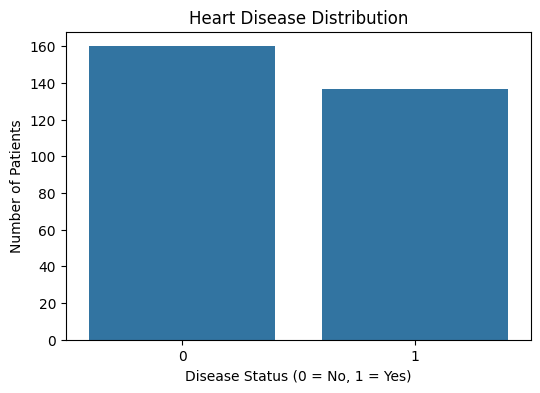

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Heart Disease Distribution")
plt.xlabel("Disease Status (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

CHECK FEATURE CORRELATION

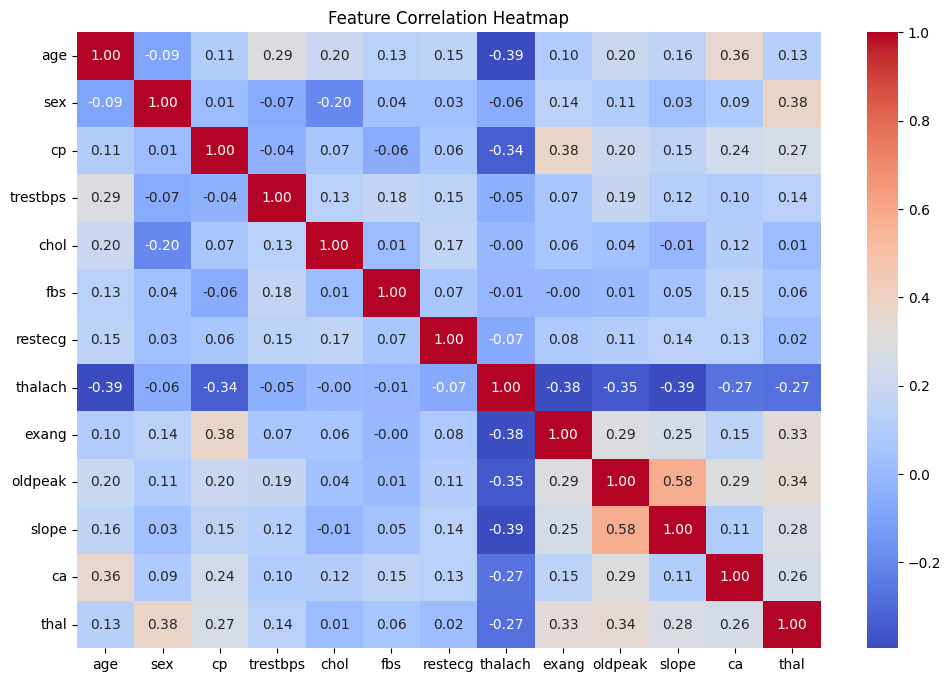

In [37]:
plt.figure(figsize=(12, 8))

correlation = X.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

SPLIT DATA INTO TRAINING AND TESTING

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (237, 13)
Testing data: (60, 13)


 SCALE THE DATA

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [40]:
X_train_scaled = scaler.fit_transform(X_train)

In [41]:
X_test_scaled = scaler.transform(X_test)